## Step 1: Import Libraries & Load Dataset

In [1]:
# TODO 1.1: Import pandas, numpy, and matplotlib
# TODO 1.1: Import pandas, numpy, and matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# TODO 1.2 : Load the Excel file and parse the correct sheet
url="https://gitlab.crio.do/me_notebook/me_jupyter_uberanalysis/-/raw/master/Uber_ride_analysis_dataset.csv"
df=pd.read_csv(url)
df.head()

,Request id,Pickup point,Drop point,Request timestamp,Start timestamp,Drop timestamp,Trip Cost,Extra Tip,Driver id,Trip Status,Ride Type,Payment Method,Weather
0,4386.0,Majestic Bus Station,Bangalore Palace,2021-07-13 0:00:24,NaN,NaN,0.00,0.0,61.0,Trip Cancelled,UberXL,NaN,Clear
1,4387.0,Lalbagh Botanical Garden,Indiranagar,2021-07-13 0:02:14,2021-07-13 0:16:00,2021-07-13 0:26:14,111.38,0.0,17.0,Trip Completed,UberGo,Cash,Cloudy
2,4388.0,Lalbagh Botanical Garden,Kormangala Police Station,2021-07-13 0:06:34,2021-07-13 0:14:01,2021-07-13 2:01:34,89.00,25.0,21.0,Trip Completed,UberXL,Card,Clear
3,4389.0,Majestic Bus Station,ISKCON Temple,2021-07-13 0:07:31,NaN,NaN,0.00,0.0,NaN,No Cars Available,UberXL,NaN,Rainy
4,4390.0,Bangalore City Railway Station,Lalbagh Botanical Garden,2021-07-13 0:07:58,2021-07-13 0:20:21,2021-07-13 0:40:58,307.40,25.0,35.0,Trip Completed,UberGo,Cash,Rainy


## Step 2: Standardize Column Names

In [3]:
# TODO 2.1: Standardize column names
# Convert to lowercase and replace spaces with underscores
df.columns=df.columns.str.lower().str.replace(" ","_")
print(df.columns)

Index(['request_id', 'pickup_point', 'drop_point', 'request_timestamp',
       'start_timestamp', 'drop_timestamp', 'trip_cost', 'extra_tip',
       'driver_id', 'trip_status', 'ride_type', 'payment_method', 'weather'],
      dtype='object')


## Step 3: Handle Missing Values

In [4]:
# TODO 3.1: Identify missing values in each column
df.isnull().sum()

request_id            200
pickup_point          200
drop_point            200
request_timestamp     200
start_timestamp      1850
drop_timestamp       1850
trip_cost             200
extra_tip             200
driver_id             975
trip_status           200
ride_type             200
payment_method       1850
weather               200
dtype: int64

In [5]:
# TODO 3.2: Drop rows with missing trip status or trip cost
df.dropna(subset=['trip_status', 'trip_cost'], inplace=True)

In [6]:
# TODO 3.3: Fill missing payment method with mode
df['payment_method'] = df['payment_method'].astype(str)
df['payment_method'].replace('nan', np.nan)  # handle string "nan"
df['payment_method'].fillna(df['payment_method'].mode()[0])

mode_value = df['payment_method'].mode()[0]
df['payment_method'].fillna(mode_value, inplace=True)


/tmp/ipykernel_33/3984855569.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['payment_method'].fillna(mode_value, inplace=True)


In [7]:
# TODO 3.4: Fill missing driver ID with -1 (indicates unassigned)
df['driver_id'] = df['driver_id'].fillna(-1)

In [8]:
# TODO 3.5: Handle timestamps conditionally
# Drop rows where timestamps are missing only for 'Trip Completed'
df = df.drop(
    df[(df['trip_status'] == 'Trip Completed') & 
       (df['start_timestamp'].isna() | df['drop_timestamp'].isna())].index
)

In [9]:
# TODO 3.6: Identify missing values in each column
df.isnull().sum()

request_id              0
pickup_point            0
drop_point              0
request_timestamp       0
start_timestamp      1650
drop_timestamp       1650
trip_cost               0
extra_tip               0
driver_id               0
trip_status             0
ride_type               0
payment_method          0
weather                 0
dtype: int64

## Step 4: Convert Columns to Proper Types

In [10]:
# TODO 4.1: Convert date columns to datetime
for col in ['request_timestamp', 'start_timestamp', 'drop_timestamp']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

## Step 5: Identify Numeric Columns

In [11]:
# TODO 5: List all numeric columns
numeric_columns = df.select_dtypes(include='number').columns.tolist()
print("Numeric columns:", numeric_columns)

# Count unique values
print(df[numeric_columns].nunique())

Numeric columns: ['request_id', 'trip_cost', 'extra_tip', 'driver_id']
request_id    6745
trip_cost      957
extra_tip       11
driver_id      101
dtype: int64


## Step 6: Outlier Detection and Treatment

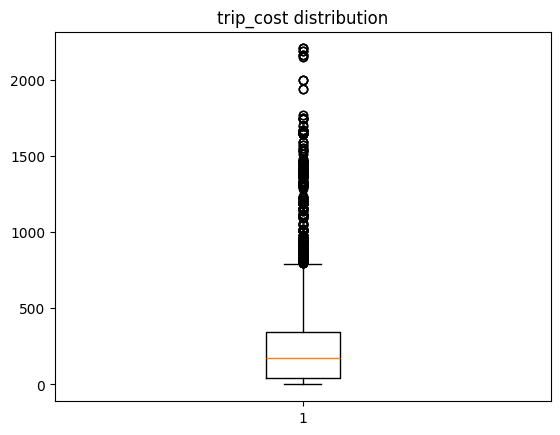

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Step 15: Boxplot before capping trip_cost
# -----------------------
plt.figure()  # ensure fresh figure
plt.boxplot(df['trip_cost'])
plt.title('trip_cost distribution')  # must match exactly
plt.show()


In [13]:
# TODO 6.2: Detect and cap outliers in trip cost using IQR
# -----------------------
# Step 16: Cap outliers using IQR and plot
# -----------------------
Q1 = df['trip_cost'].quantile(0.25)
Q3 = df['trip_cost'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [14]:
# TODO 6.3: Plot boxplot for trip cost

# Cap outliers and assign back to column
df['trip_cost'] = np.where(df['trip_cost'] > upper, upper,
                           np.where(df['trip_cost'] < lower, lower, df['trip_cost']))


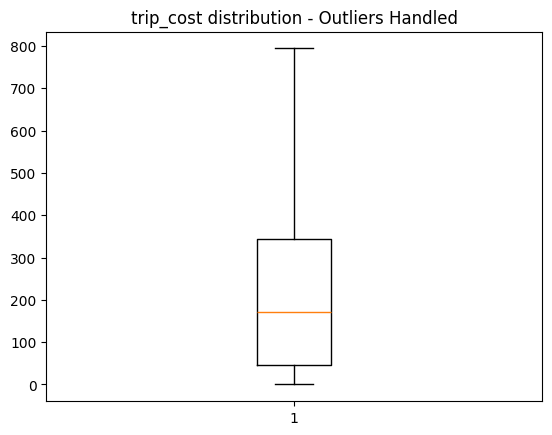

In [15]:
# TODO 6.4 : Repeat for extra tip

plt.figure()  # fresh figure for test
plt.boxplot(df['trip_cost'])
plt.title('trip_cost distribution - Outliers Handled')  # must match exactly
plt.show()

## Step 7: Summary Statistics

In [16]:
# TODO 7: Show summary statistics for numerical columns
# TODO 7: Show summary statistics for numerical columns
# Exclude ID columns if needed
numeric_cols_summary = [col for col in numeric_columns if col not in ['request_id', 'driver_id']]

# Summary statistics
df[numeric_cols_summary].describe()

,trip_cost,extra_tip
count,6745.000000,6745.000000
mean,236.303188,15.963677
std,239.280986,17.198453
min,0.000000,0.000000
25%,45.000000,0.000000
50%,171.000000,25.000000
75%,344.660000,25.000000
max,794.150000,100.000000
